## Import all the necessary config files

In [1]:
from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

np.random.seed(42)
random.seed(42)
#if you get an error here you propoably didnt close the parameters excel sheet

In [2]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'Run'

## Run the coral model

In [3]:
print(growth_rate_df)

   CoralType  GrowthRate_cm_per_year
0  Branching                     2.5
1    Foliose                     3.0
2      Other                     1.0


In [4]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear) # no PDS_df because it’s a placeholder. It basically asks a user to link SOME data frame to it. Same as run_model_n_times(n_iterations) simply tells a user that there should be some number in those brackets that will become the number of iterations. 

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,2.600000,7.300000,8.000000,17.900000
1,1,2.835066,8.246453,8.920062,20.001581
2,2,3.241118,9.499303,10.556508,23.296928
3,3,3.797117,11.239051,12.336016,27.372184
4,4,4.489337,13.646642,14.954060,33.090040
5,5,5.182352,16.019113,16.652915,37.854380
6,6,5.790186,18.201715,18.285690,42.277591
7,7,6.309355,19.952957,19.720658,45.982971
8,8,6.707788,21.270363,20.869393,48.847544
9,9,7.000045,22.271574,21.698022,50.969641


## Plot the change in total coral cover over the years

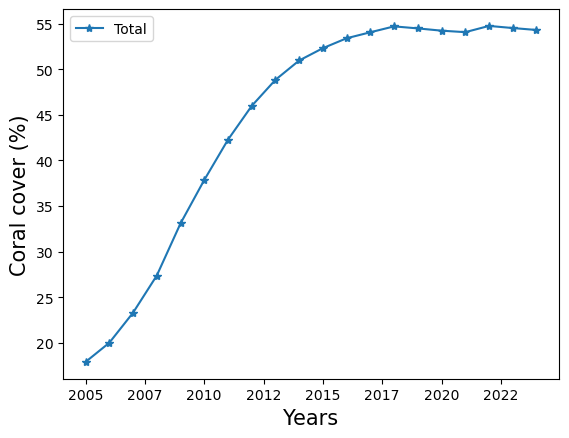

In [5]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [6]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot
0,0,89.100000,43.300000,2.400000,4.000000,0.800000,36.100000,36.800000,4.000000,5.000000,17.900000,45.800000,107.000000
1,1,79.998419,41.753975,2.100447,4.012253,0.736572,31.594225,33.882300,3.069049,4.603573,20.001581,45.133333,106.888889
2,2,76.703072,35.574407,1.919014,4.092413,0.737391,28.865171,33.920000,2.560386,4.608696,23.296928,41.043414,99.914749
3,3,72.627816,31.894343,1.696443,3.973724,0.738114,25.517326,33.953249,2.135747,4.613213,27.372184,40.662351,99.928878
4,4,66.909960,26.504382,1.386650,3.544963,0.738769,20.857521,33.983381,1.781369,4.617307,33.090040,40.346252,99.940674
5,5,62.145620,22.010976,1.131378,3.139972,0.739358,17.017808,34.010461,1.485657,4.620987,37.854380,40.085162,99.950518
6,6,57.722409,17.811645,0.896955,2.695854,0.739887,13.491693,34.034794,1.238933,4.624293,42.277591,39.869495,99.958732
7,7,54.017029,14.291083,0.702866,2.284692,0.740359,10.572278,34.056492,1.033102,4.627241,45.982971,39.691531,99.965585
8,8,51.152456,11.579108,0.554694,1.946620,0.740774,8.343520,34.075609,0.861402,4.629838,48.847544,39.544651,99.971303
9,9,49.030359,9.583149,0.446370,1.686171,0.741136,6.714152,34.092247,0.718185,4.632099,50.969641,39.423282,99.976072


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

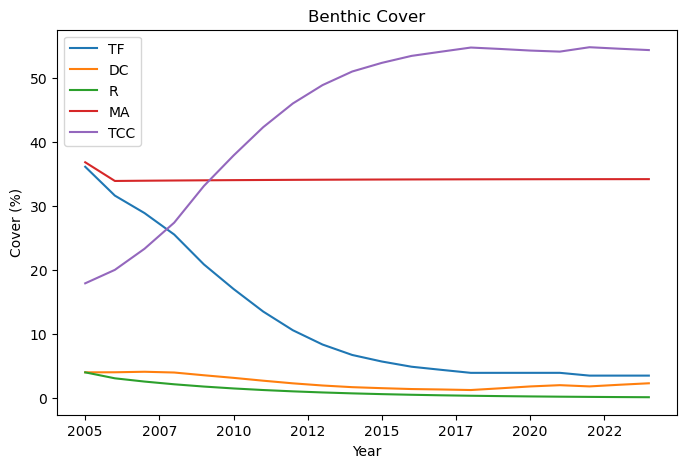

In [7]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [8]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots - please enter the years (within model range) for each plot

(6, 10, 13, 17)


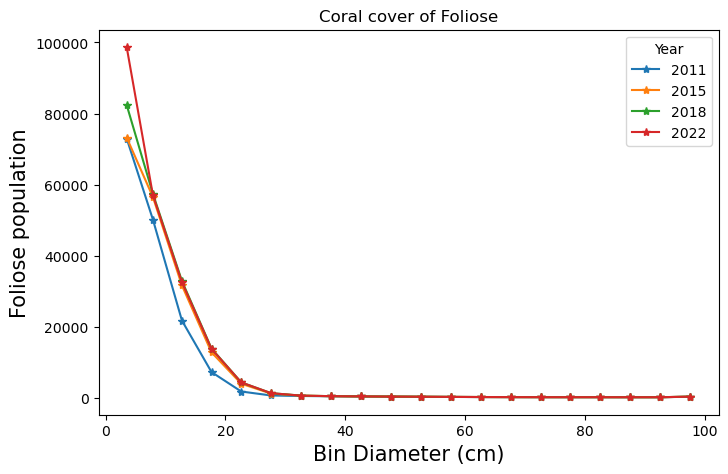

In [9]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    # Convert them to model years (indices) for the model
    model_years = tuple(year - year_start for year in Years)
    print(model_years)
    # Plot coral population change by type
    plot_coral_type_population_change('Foliose', False, *model_years)

(6, 10, 13, 17)


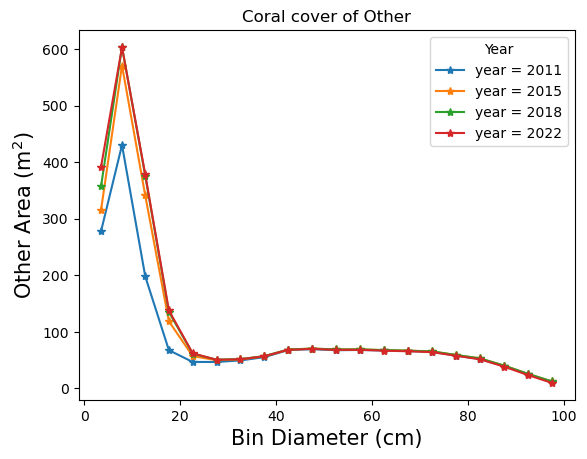

In [10]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    print(model_years)

    #Plot coral area change by type
    plot_coral_type_areal_change('Other', False, *model_years)

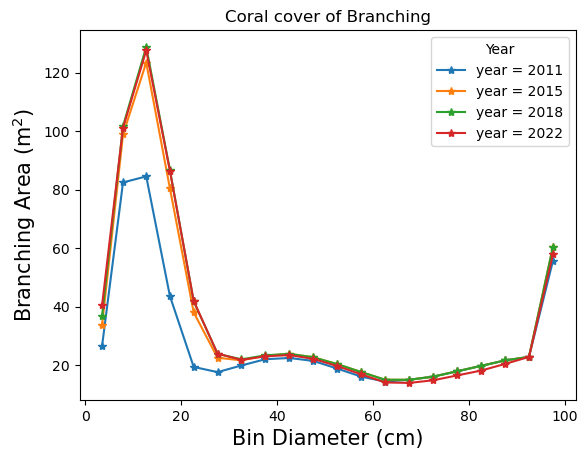

In [11]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Branching', False, *model_years)

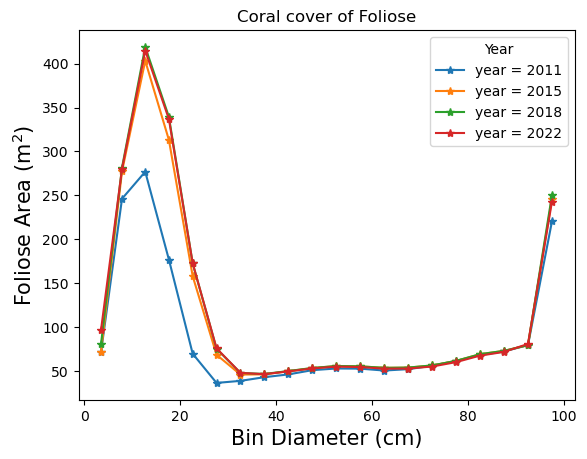

In [12]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:

    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Foliose',False, *model_years)

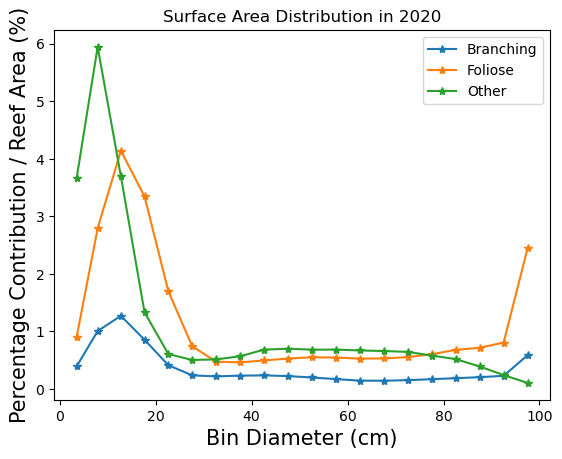

In [13]:
# Plot surface area distribution of different coral types in a given year.

Year = 2020

# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_surface_area_distribution(model_year)

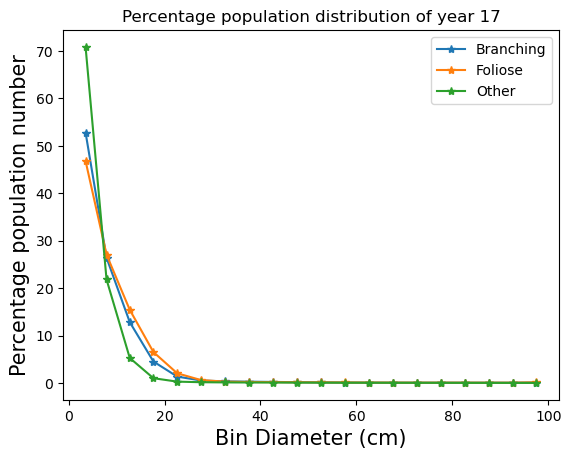

In [14]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2022
# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_population_distribution_in_percentage(model_year)

## Rugosity

In [15]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

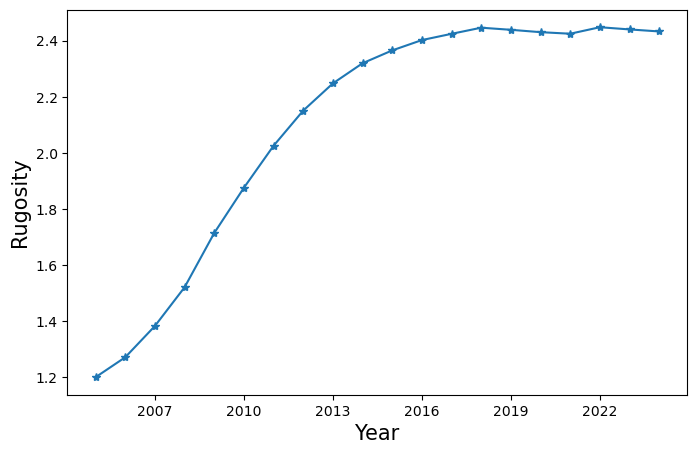

In [16]:
# This function plots the rugosity values over the years

plot_rugosity_year()

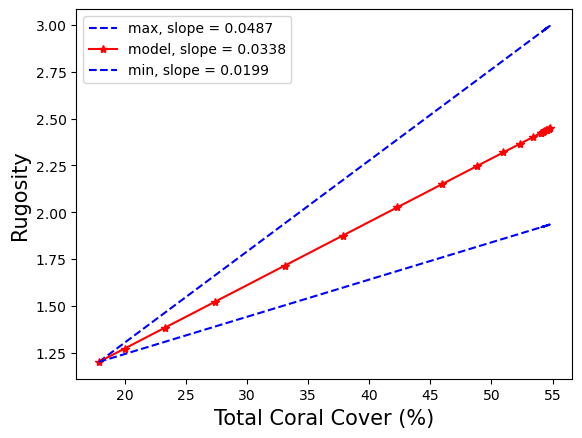

In [17]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

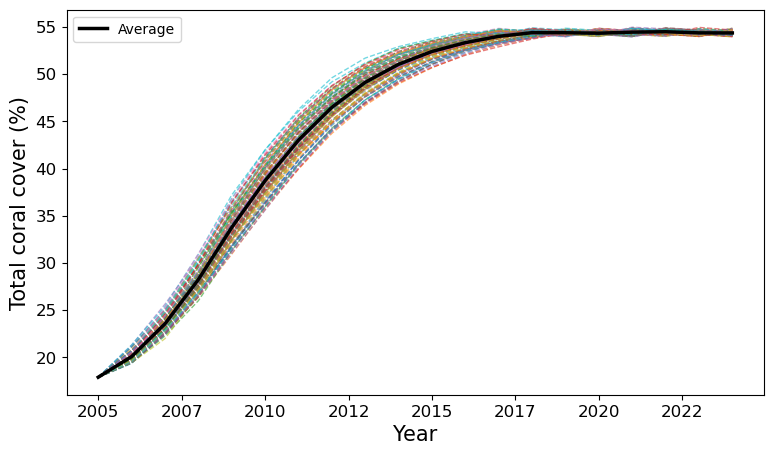

In [18]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [19]:
iteration_df

,year,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_92,iteration_93,iteration_94,iteration_95,iteration_96,iteration_97,iteration_98,iteration_99,iteration_100,averaged
0,0,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,...,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000
1,1,19.719361,19.610195,19.422330,19.935418,19.441934,20.689357,19.722128,19.676245,20.833886,...,19.565702,19.816310,20.341168,20.546290,19.426736,20.286636,19.554581,19.651562,19.570653,20.088339
2,2,23.011709,22.657689,22.270365,23.648437,22.500998,23.964972,23.081752,23.220505,24.898262,...,23.205200,23.019235,24.573987,23.704802,22.445691,24.358940,23.248192,22.802257,22.879369,23.555620
3,3,27.621438,26.368798,25.999206,27.977562,26.972937,28.680347,28.123485,28.155490,30.013508,...,28.506279,27.525805,29.860537,28.346320,26.454571,29.267794,27.575836,27.196663,26.874209,28.244692
4,4,33.505659,30.926487,31.283110,32.949691,31.736175,33.988067,33.414547,33.593806,36.489427,...,35.010584,33.584716,36.363665,34.045062,32.405615,34.341337,32.866588,32.311539,31.453254,33.755369
5,5,38.811932,35.654713,35.946871,37.554478,36.602232,38.653773,38.550675,38.755758,41.256520,...,40.428709,39.062926,41.460305,39.090164,37.446413,39.211034,38.185201,37.379174,35.948317,38.705777
6,6,43.288192,39.933558,40.449123,41.519662,40.907467,43.076595,42.812320,43.167234,45.248259,...,44.842325,43.376662,45.617974,43.551456,41.851046,43.179534,42.948946,41.739983,40.434443,43.001531
7,7,47.076706,43.716140,44.282080,44.865629,44.757315,46.496655,46.347850,46.876116,48.515038,...,48.311182,46.870099,48.768802,47.181830,45.516469,46.484100,46.514844,45.463960,44.022439,46.482253
8,8,49.654183,46.694774,47.264685,47.573223,47.655657,49.075362,48.915868,49.328595,50.914346,...,50.699105,49.579931,51.041331,49.745662,48.392924,49.018878,49.155101,48.441319,47.303629,49.127840
9,9,51.667020,48.960953,49.587503,49.754213,49.889485,50.907777,50.687708,51.193754,52.393123,...,52.255842,51.437626,52.598830,51.474797,50.652016,50.741487,50.995875,50.558391,49.476052,51.042097


In [20]:
# Real data input should be saved in the coral_data_and_custom_parameters.xlsx file
# Load the Excel file into a DataFrame

# Load Excel
real_df_raw = pd.read_excel("coral_data_and_custom_parameters.xlsx", sheet_name="Real_Cover")

# Fill + mask (returns a tuple)
real_df, created = fill_nans_columnwise(
    real_df_raw,
    year_col='Year',
    make_full_years=False,
    fallback='mean',
    return_mask=True
)

# Make Year integer-like for display
real_df['Year'] = pd.to_numeric(real_df['Year'], errors='coerce').round().astype('Int64')

value_cols = [c for c in real_df.columns if c != 'Year']

# Build red-highlight styles
styles = created.reindex_like(real_df).replace({True: 'color: red', False: ''})

# Display with exactly 2 decimals (and integer Year)
styler = (
    real_df.style
           .format({c: '{:.2f}' for c in value_cols})
           .format({'Year': '{:.0f}'})
           .apply(lambda _: styles, axis=None)
)
display(styler)


,Year,RealBranching_Area (%),RealFoliose_Area (%),RealOther_Area (%)
0,2000,1.200000,2.200000,16.300000
1,2001,1.550000,2.200000,17.400000
2,2002,1.900000,2.200000,18.500000
3,2003,3.000000,2.450000,17.400000
4,2004,4.100000,2.700000,16.300000
5,2005,6.050000,2.700000,15.200000
6,2006,8.000000,2.700000,14.100000
7,2007,10.500000,2.550000,13.500000
8,2008,13.000000,2.400000,12.900000
9,2009,14.200000,2.700000,17.200000


## Run the model through a number iterations for all parameters and export results

In [21]:
#setting seed to ensure repeatability of runs 

np.random.seed(42)
random.seed(42)

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)
area_df.iloc[:, 2:] = (area_df.iloc[:, 2:] * 100).clip(upper=100)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# FIX: Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            2.600000          7.300000        8.000000   
1      1            2.835066          8.246453        8.920062   
2      2            3.241118          9.499303       10.556508   
3      3            3.797117         11.239051       12.336016   
4      4            4.489337         13.646642       14.954060   
..   ...                 ...               ...             ...   
15    15            9.393856         25.571737       19.047450   
16    16            9.498411         25.789041       19.282395   
17    17            9.442199         25.673543       19.217885   
18    18            9.392217         25.541412       19.132508   
19    19            9.480709         25.729022       19.480371   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               17.900000                89.100000                43.300000   
1               20.001581        

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

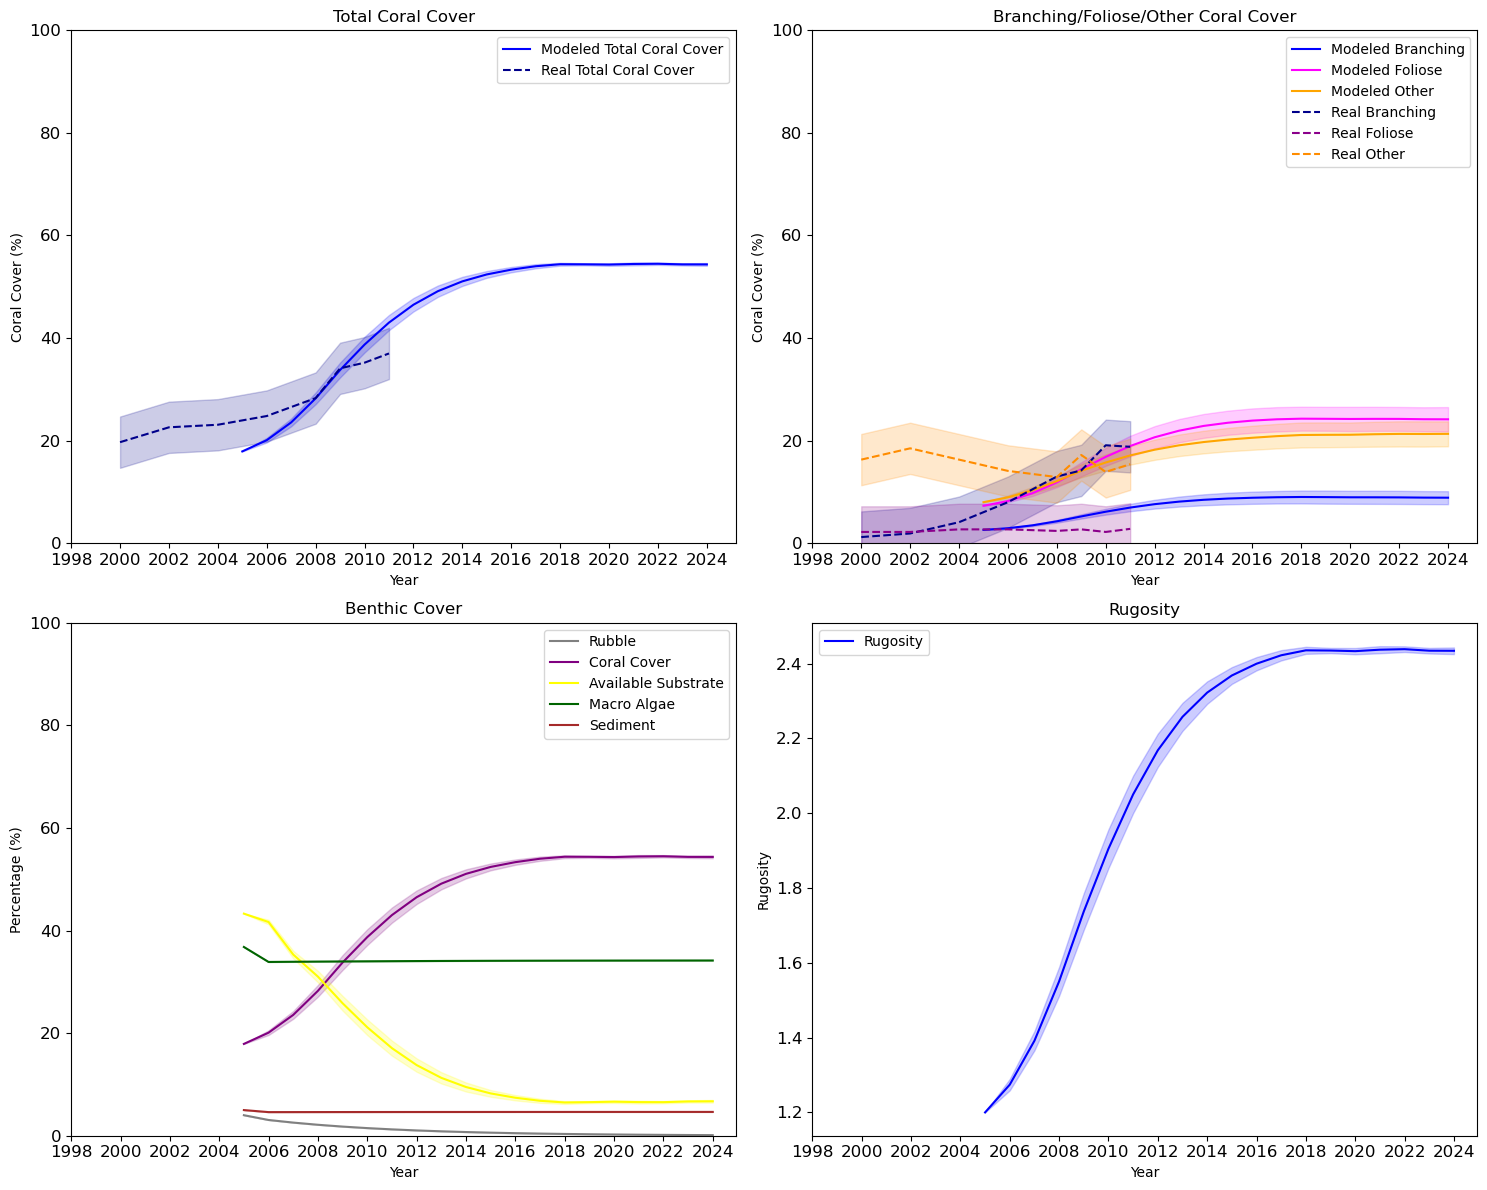

In [22]:
# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

#Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Plot Total Coral Cover
axs[0, 0].plot(actual_years, average_total.astype(float), label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years, (average_total - std_dev_total).astype(float), (average_total + std_dev_total).astype(float), color='blue', alpha=0.2)
axs[0, 0].plot(real_df['Year'].astype(float), real_df['Total_Coral_Cover (%)'].astype(float), label='Real Total Coral Cover', color='darkblue', linestyle='--')
axs[0, 0].fill_between(real_df['Year'].astype(float), (real_df['Total_Coral_Cover (%)'].astype(float) - real_total_margin), (real_df['Total_Coral_Cover (%)'].astype(float) + real_total_margin), color='darkblue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 100)
axs[0, 0].set_xticks(actual_years)
axs[0, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(actual_years, average_branching.astype(float), label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years, (average_branching - std_dev_branching).astype(float), (average_branching + std_dev_branching).astype(float), color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose.astype(float), label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years, (average_foliose - std_dev_foliose).astype(float), (average_foliose + std_dev_foliose).astype(float), color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other.astype(float), label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years, (average_other - std_dev_other).astype(float), (average_other + std_dev_other).astype(float), color='orange', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealBranching_Area (%)'].astype(float), label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealBranching_Area (%)'].astype(float) - real_branching_margin), (real_df['RealBranching_Area (%)'].astype(float) + real_branching_margin), color='darkblue', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealFoliose_Area (%)'].astype(float), label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealFoliose_Area (%)'].astype(float) - real_foliose_margin), (real_df['RealFoliose_Area (%)'].astype(float) + real_foliose_margin), color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealOther_Area (%)'].astype(float), label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealOther_Area (%)'].astype(float) - real_other_margin), (real_df['RealOther_Area (%)'].astype(float) + real_other_margin), color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

#years_benthic = average_rubble.index
#actual_years_benthic = [year + year_start for year in years]

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])

# After your plotting code:
# Get current x-axis limits
xlim = axs[0, 0].get_xlim()

# Create integer ticks from start to end
year_ticks = list(range(int(xlim[0]), int(xlim[1])+1, 2)) 
axs[0, 0].set_xticks(year_ticks)
axs[0, 0].set_xticklabels([str(year) for year in year_ticks])

axs[1, 0].set_xticks(year_ticks)
axs[1, 0].set_xticklabels([str(year) for year in year_ticks])

axs[0, 1].set_xticks(year_ticks)
axs[0, 1].set_xticklabels([str(year) for year in year_ticks])

axs[1, 1].set_xticks(year_ticks)
axs[1, 1].set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs.png')
plt.savefig(graph_path)
plt.show()

## Create bubble plot for population distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


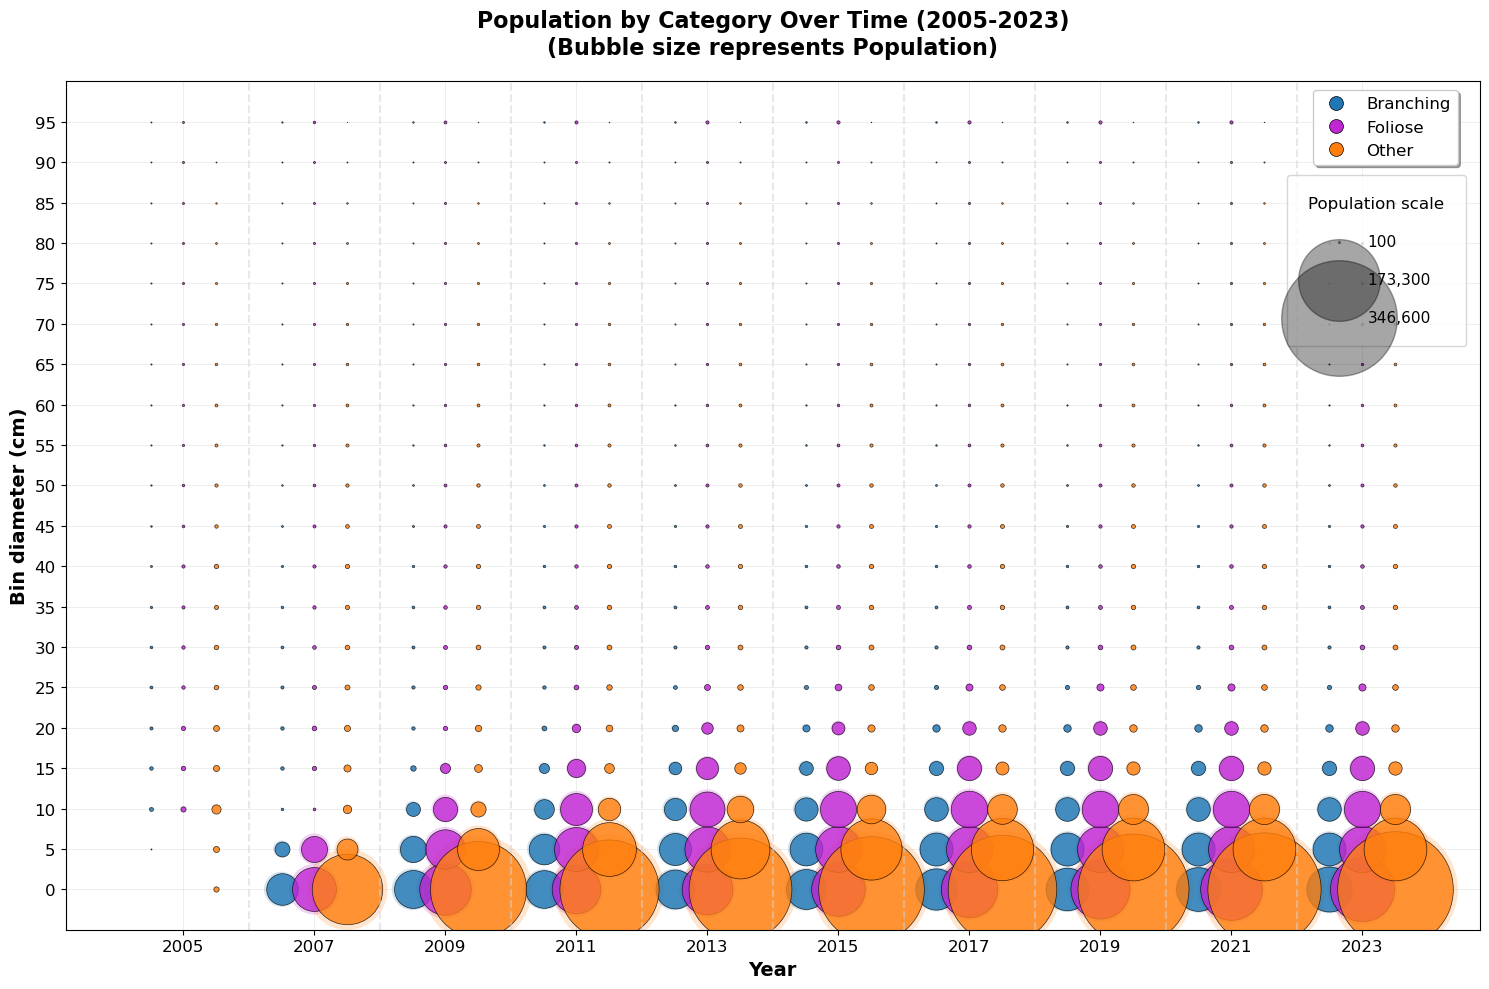

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Population by Category Over Time (2005-2023)\n(Bubble size represents Population)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [23]:
plot_bubble_chart_from_dataframe(population_size_df, 
                                title = "Population",
                                category_col="MG", 
                                year_interval=2, 
                                bubble_scale=0.02,
                                parallel_offset = 0.5,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.08,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Create bubble plot for percentage of population distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


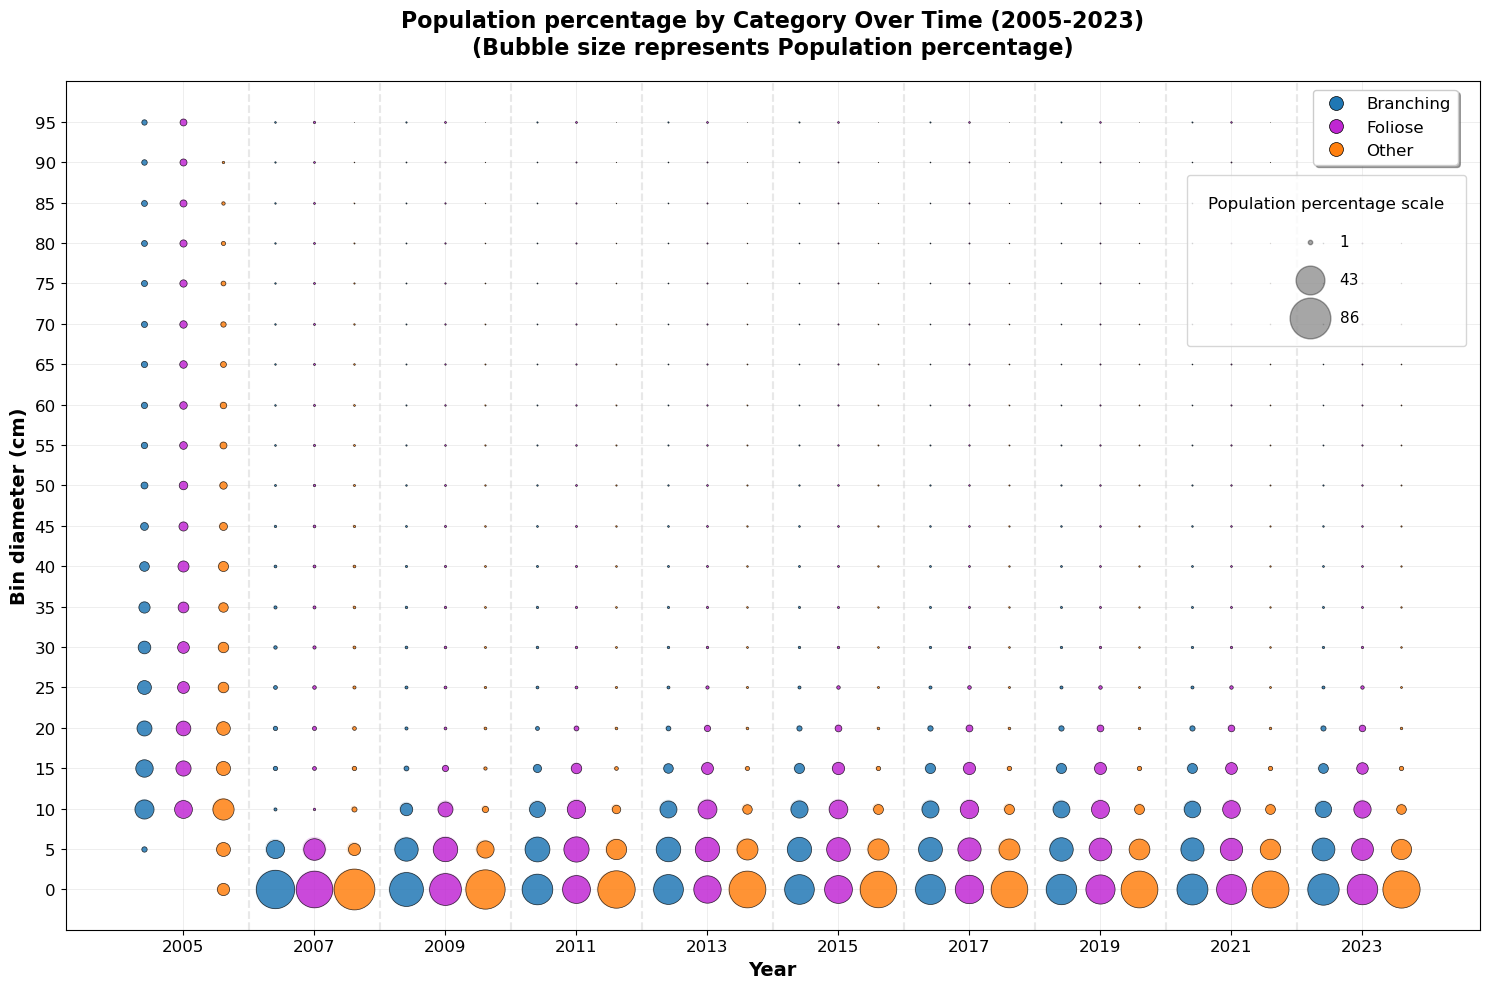

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Population percentage by Category Over Time (2005-2023)\n(Bubble size represents Population percentage)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [24]:
plot_bubble_chart_from_dataframe(percentage_population_size_df, 
                                title = "Population percentage",
                                category_col="MG", 
                                year_interval=2,  
                                bubble_scale=10,
                                parallel_offset = 0.6,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.1,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Create bubble plot for area distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


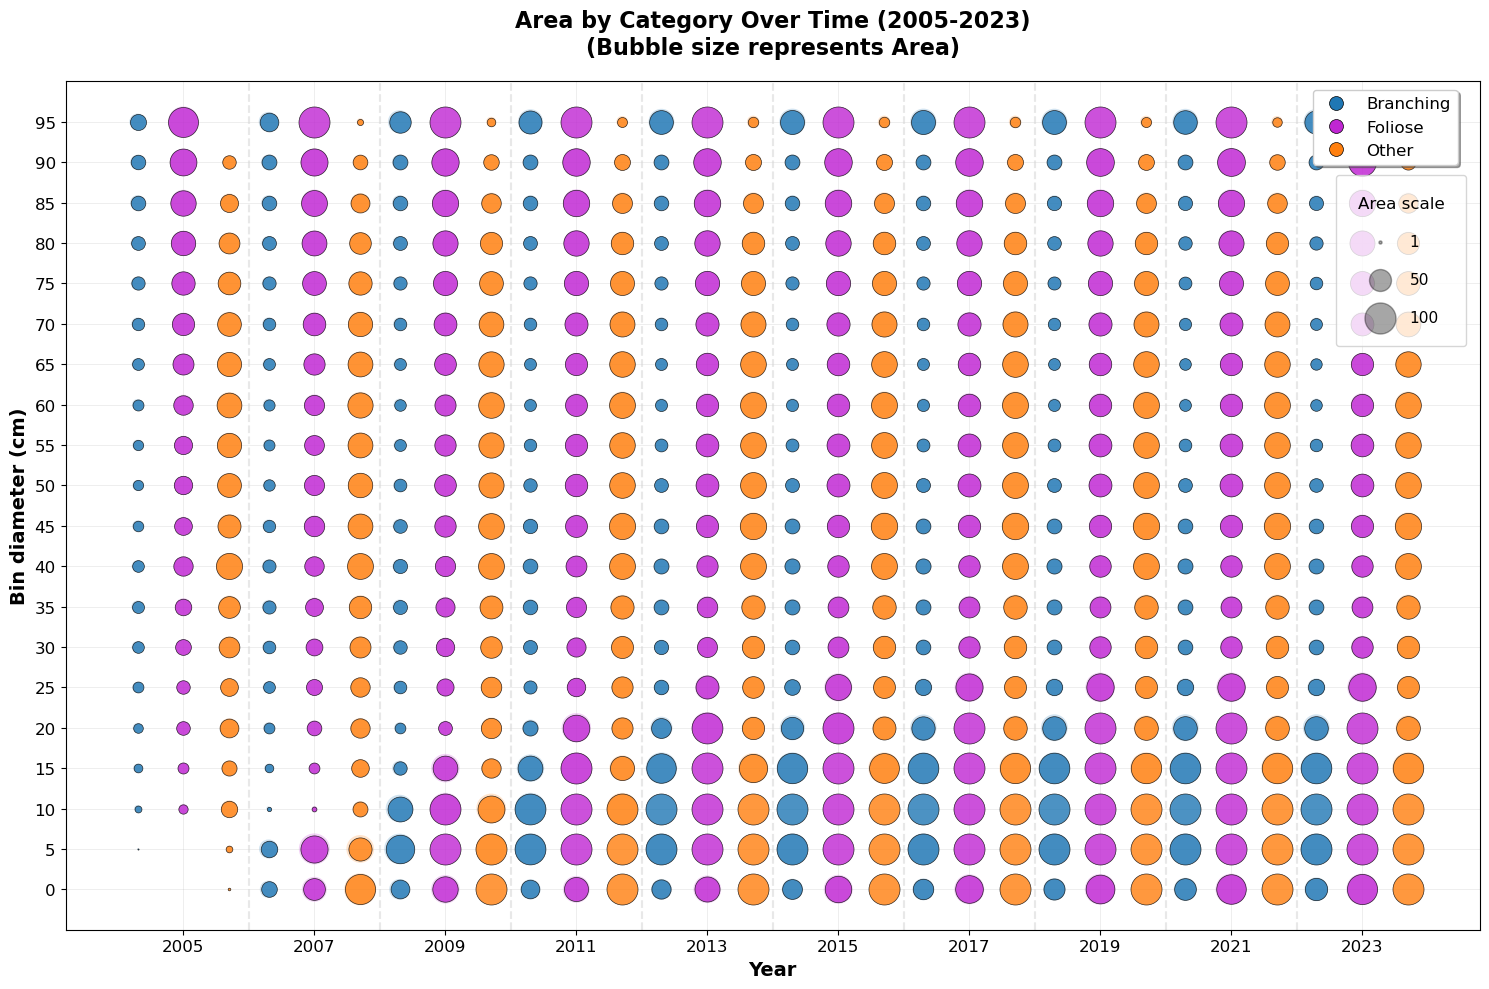

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Area by Category Over Time (2005-2023)\n(Bubble size represents Area)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [25]:
plot_bubble_chart_from_dataframe(area_df, 
                                title = "Area",
                                category_col="MG", 
                                year_interval=2, 
                                bubble_scale=5,
                                parallel_offset = 0.7,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.7,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Calculate and plot average and standard deviation for each morphology based on multiple iterations of model

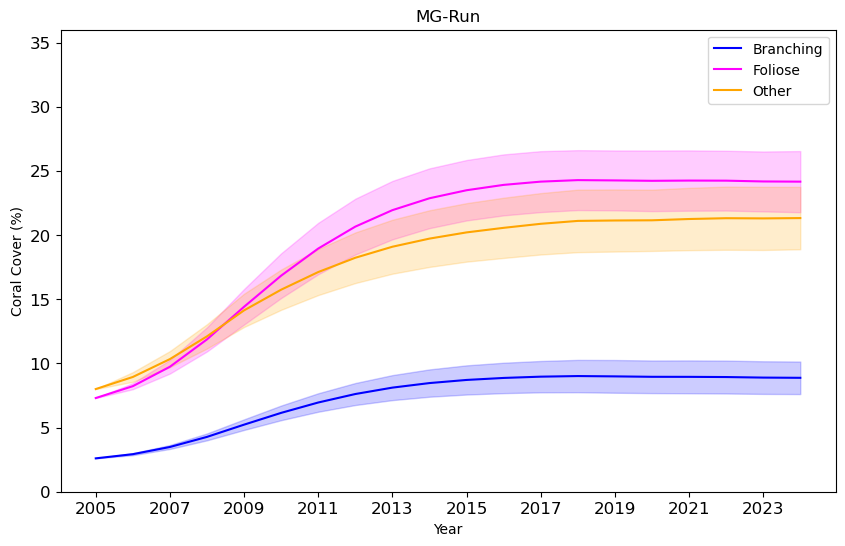

Graph has been saved to output/figures\MG-Run.png


In [26]:
# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

# Plot the average results with standard deviation
plt.figure(figsize=(10, 6))
# Convert model years -> actual years for x-axis
years_model = average_branching.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_branching, label='Branching', color='blue')
plt.fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)

plt.plot(years, average_foliose, label='Foliose', color='fuchsia')
plt.fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)

plt.plot(years, average_other, label='Other', color='orange')
plt.fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Coral Cover (%)')
plt.ylim(0, 36)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'MG-{title}')
plt.legend()

# Define the graph directory path
graph_dir = 'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the plot to the specified folder
graph_path = os.path.join(graph_dir, f'MG-{title}.png')
plt.savefig(graph_path)
plt.show()

print(f"Graph has been saved to {graph_path}")

## Plot substrate based on multiple iterations

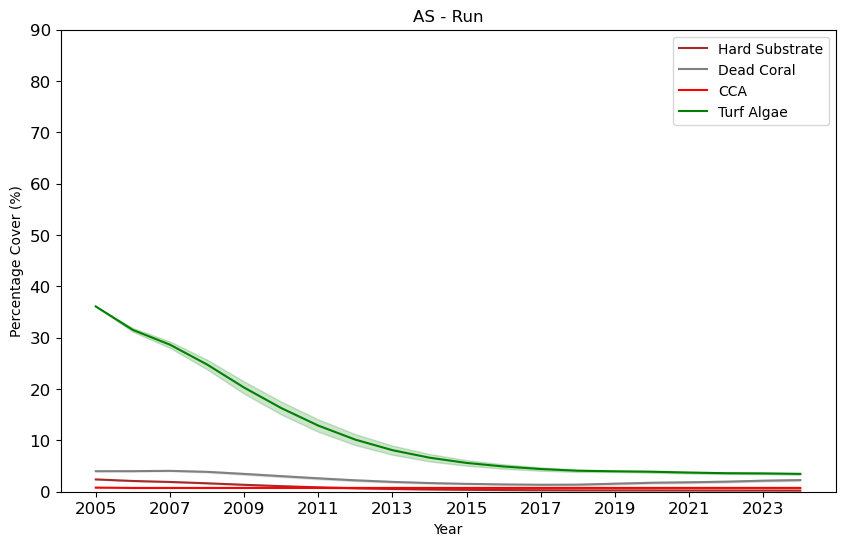

AS graph has been saved to output/figures\AS-Run.png


In [27]:
#Plot AS-title
# Calculate the average and standard deviation for each benthic cover type
average_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].mean()
std_dev_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].std()

average_dead_coral = final_df.groupby('Year')['dead_coral (%)'].mean()
std_dev_dead_coral = final_df.groupby('Year')['dead_coral (%)'].std()

average_cca = final_df.groupby('Year')['CCA (%)'].mean()
std_dev_cca = final_df.groupby('Year')['CCA (%)'].std()

average_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].mean()
std_dev_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))

# Convert model years -> actual years for x-axis
years_model = average_hard_substrate.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_hard_substrate, label='Hard Substrate', color='brown')
plt.fill_between(years, average_hard_substrate - std_dev_hard_substrate, average_hard_substrate + std_dev_hard_substrate, color='brown', alpha=0.2)

plt.plot(years, average_dead_coral, label='Dead Coral', color='grey')
plt.fill_between(years, average_dead_coral - std_dev_dead_coral, average_dead_coral + std_dev_dead_coral, color='grey', alpha=0.2)

plt.plot(years, average_cca, label='CCA', color='red')
plt.fill_between(years, average_cca - std_dev_cca, average_cca + std_dev_cca, color='red', alpha=0.2)

plt.plot(years, average_turfing_algae, label='Turf Algae', color='green')
plt.fill_between(years, average_turfing_algae - std_dev_turfing_algae, average_turfing_algae + std_dev_turfing_algae, color='green', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage Cover (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'AS - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_as = os.path.join(graph_dir, f'AS-{title}.png')
plt.savefig(graph_path_as)
plt.show()

print(f"AS graph has been saved to {graph_path_as}")

## Plot benthic cover based on multiple iterations

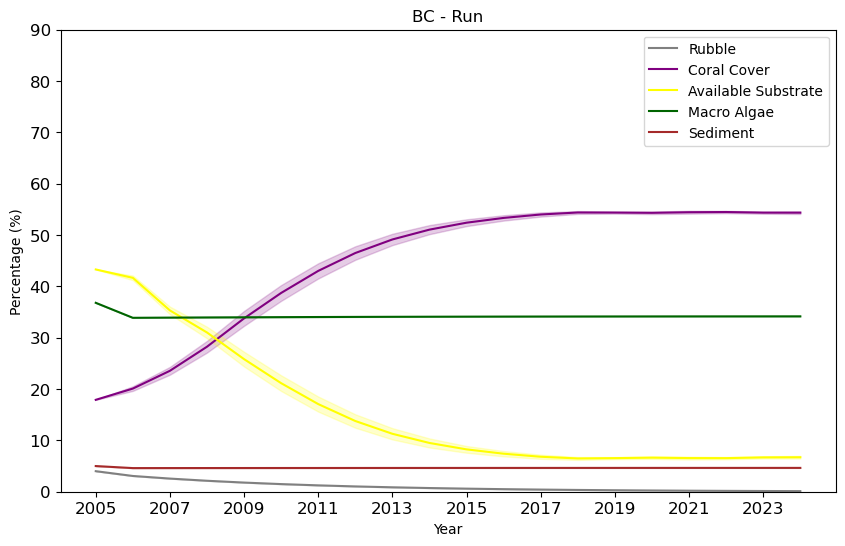

BC graph has been saved to output/figures\BC-Run.png


In [28]:
#plot benthic cover 
# Calculate the average and standard deviation for each benthic cover type
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()

average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()

average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()

average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()

average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))
years_model = average_rubble.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)  

plt.plot(years, average_rubble, label='Rubble', color='grey')
plt.fill_between(years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)

plt.plot(years, average_coral_cover, label='Coral Cover', color='purple')
plt.fill_between(years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)

plt.plot(years, average_as, label='Available Substrate', color='yellow')
plt.fill_between(years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)

plt.plot(years, average_ma, label='Macro Algae', color='darkgreen')
plt.fill_between(years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)

plt.plot(years, average_sediment, label='Sediment', color='brown')
plt.fill_between(years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'BC - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_bc = os.path.join(graph_dir, f'BC-{title}.png')
plt.savefig(graph_path_bc)
plt.show()

print(f"BC graph has been saved to {graph_path_bc}")

## Plot rugosity based on multiple iterations

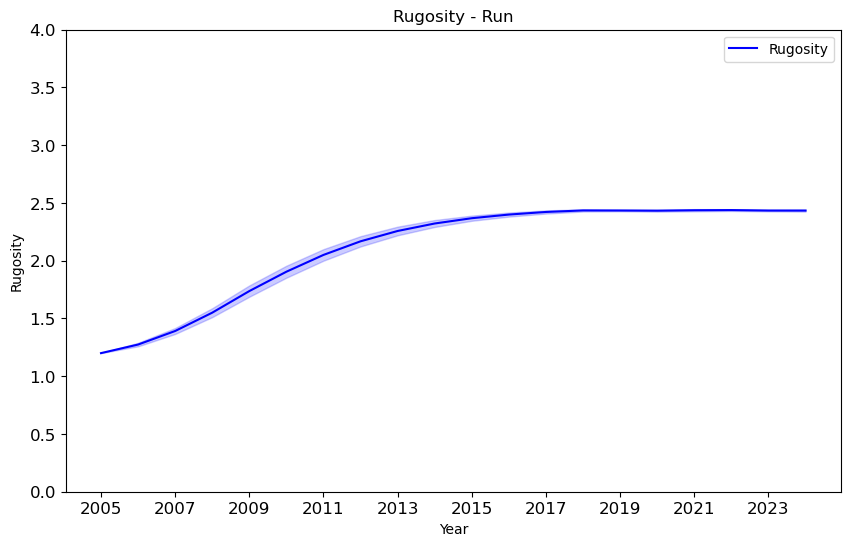

Rugosity graph has been saved to output/figures\Rugosity-Run.png


In [29]:
#plot rugosity
# Calculate the average and standard deviation for rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# Plot the average results with standard deviation for rugosity
plt.figure(figsize=(10, 6))
years_model = average_rugosity.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int) 

plt.plot(years, average_rugosity, label='Rugosity', color='blue')
plt.fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Rugosity')
plt.ylim(0, 4)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'Rugosity - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_rugosity = os.path.join(graph_dir, f'Rugosity-{title}.png')
plt.savefig(graph_path_rugosity)
plt.show()

print(f"Rugosity graph has been saved to {graph_path_rugosity}")

## Predicting the effect of a cyclone on the whole colony mortality

In [30]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

,Branching,Foliose,Other
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,0,0


## The effect of bleaching on the partial colony mortality

In [31]:
# PCM_rates are the background partial colony mortality rates under no external stressor
# PCM_rates_during_bleaching is the calculated partial colony mortality rates during bleaching event

branching_bleaching_rate = 34
foliose_bleaching_rate = 17
other_bleaching_rate = 17

dhw = 8

PCM_rates_during_bleaching = get_PCM_rates_after_dhw(PCM_rates, dhw, branching_bleaching_rate, foliose_bleaching_rate, other_bleaching_rate)
PCM_rates_during_bleaching

,Branching,Foliose,Other
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,0,0


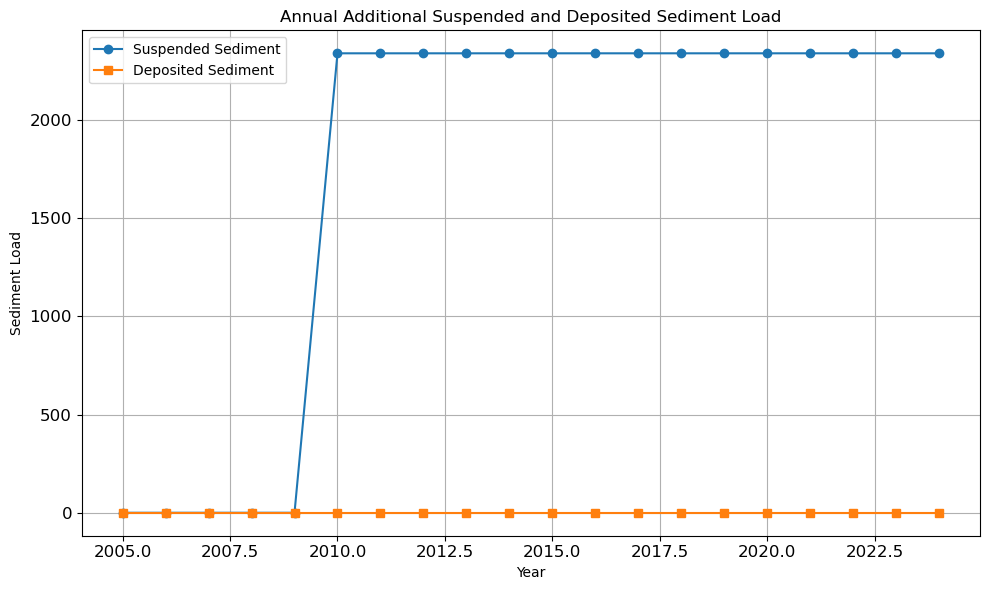

In [32]:
import matplotlib.pyplot as plt

# Build lists of years and sediment values
years = list(range(year_start, year_end + 1))
model_years = [y - year_start for y in years]

suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]

plt.figure(figsize=(10, 6))
plt.plot(years, suspended, label='Suspended Sediment', marker='o')
plt.plot(years, deposited, label='Deposited Sediment', marker='s')
plt.xlabel('Year')
plt.ylabel('Sediment Load')
plt.title('Annual Additional Suspended and Deposited Sediment Load')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
#Rio testing 
# Example usage: print the adjusted growth rates DataFrame for a specific year

# Choose the year you want to inspect (e.g., year 0)
year = 0

# Call the function to get the adjusted growth rates DataFrame
growth_rate_ss = get_GR_after_ss(
    growth_rate,              # your base growth rate DataFrame
    add_sedi_exp_per_year,    # your sediment exposure dictionary
    year,                     # the year index you want
    sedi_exp_growth_coeff         # your sediment susceptibility coefficients
)

# Print the DataFrame
print(growth_rate_ss)

    Branching   Foliose     Other
0    5.000000  6.000000  2.000000
1    5.000000  6.000000  2.000000
2    4.883331  5.859998  1.953333
3    4.766663  5.719995  1.906665
4    4.649994  5.579993  1.859998
5    4.533326  5.439991  1.813330
6    4.416657  5.299988  1.766663
7    4.299988  5.159986  1.719995
8    4.183320  5.019984  1.673328
9    4.066651  4.879982  1.626661
10   3.949983  4.739979  1.579993
11   3.833314  4.599977  1.533326
12   3.716645  4.459975  1.486658
13   3.599977  4.319972  1.439991
14   3.483308  4.179970  1.393323
15   3.366640  4.039968  1.346656
16   3.249971  3.899965  1.299988
17   3.133303  3.759963  1.253321
18   3.016634  3.619961  1.206654
19   2.899965  3.479958  1.159986


In [34]:
# Choose the year you want to inspect (e.g., year 0)
year = 0

# Call the function to get the adjusted PCM rates DataFrame
pcm_rates_ds = get_PCM_rates_after_DS_exp(
    PCM_rates,             # your base PCM rates DataFrame
    add_sedi_exp_per_year, # your sediment exposure dictionary
    year,                  # the year index you want
    sedi_exp_PCM_coeff     # your sediment PCM coefficients
)

# Print the DataFrame
print(pcm_rates_ds)

    Branching  Foliose  Other
0           0        0      0
1           0        0      0
2           0        0      0
3           0        0      0
4           0        0      0
5           0        0      0
6           0        0      0
7           0        0      0
8           0        0      0
9           0        0      0
10          0        0      0
11          0        0      0
12          0        0      0
13          0        0      0
14          0        0      0
15          0        0      0
16          0        0      0
17          0        0      0
18          0        0      0
19          0        0      0


In [35]:
from pprint import pprint
import pandas as pd

names = [
    'sediment_df',
    'sediment_years',
    'add_sedi_exp_per_year',
    'suspended',
    'deposited',
    'sedi_exp_growth_coeff',
    'sedi_exp_PCM_coeff'
]

def _print_var(name):
    g = globals()
    print(f"\n=== {name} ===")
    if name in g:
        val = g[name]
        try:
            if isinstance(val, pd.DataFrame):
                # show the dataframe (first rows) for readability
                display(val.head())
                return
        except Exception:
            pass
        pprint(val)
    else:
        print("NOT FOUND")

# If suspended/deposited are not defined but add_sedi_exp_per_year + year range exist, build them
if 'add_sedi_exp_per_year' in globals() and (('suspended' not in globals()) or ('deposited' not in globals())):
    if 'year_start' in globals() and 'year_end' in globals():
        years = list(range(year_start, year_end + 1))
        model_years = [y - year_start for y in years]
        suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
        deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]
        # attach to globals so the subsequent prints find them
        globals()['suspended'] = suspended
        globals()['deposited'] = deposited

for n in names:
    _print_var(n)


=== sediment_df ===


,Year,Month,Suspended_sediment,Deposited_sediment
0,2005,1,5,10
1,2005,2,5,10
2,2005,3,5,10
3,2005,4,5,10
4,2005,5,5,10



=== sediment_years ===
NOT FOUND

=== add_sedi_exp_per_year ===
{0: (0.0, 0.0),
 1: (0.0, 0.0),
 2: (0.0, 0.0),
 3: (0.0, 0.0),
 4: (0.0, 0.0),
 5: (2340.0, 0.0),
 6: (2340.0, 0.0),
 7: (2340.0, 0.0),
 8: (2340.0, 0.0),
 9: (2340.0, 0.0),
 10: (2340.0, 0.0),
 11: (2340.0, 0.0),
 12: (2340.0, 0.0),
 13: (2340.0, 0.0),
 14: (2340.0, 0.0),
 15: (2340.0, 0.0),
 16: (2340.0, 0.0),
 17: (2340.0, 0.0),
 18: (2340.0, 0.0),
 19: (2340.0, 0.0)}

=== suspended ===
[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0,
 2340.0]

=== deposited ===
[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

=== sedi_exp_growth_coeff ===
{'Branching': -0.00997, 'Foliose': -0.00272, 'Other': -0.00533}

=== sedi_exp_PCM_coeff ===
{'Branching': 0.3296, 'Foliose': 0.0724, 'Other': 0.1645}


In [36]:
from pprint import pprint

# Print `additional_sediment_exposure` if present; otherwise fall back to known variables
# (relies on `pprint` imported in another cell)

if 'additional_sediment_exposure' in globals():
    print("additional_sediment_exposure:")
    pprint(globals()['additional_sediment_exposure'])

else:
    print("additional_sediment_exposure not found and cannot be constructed from available data.")

additional_sediment_exposure:
{(0, 1): (0.0, 0.0),
 (0, 2): (0.0, 0.0),
 (0, 3): (0.0, 0.0),
 (0, 4): (0.0, 0.0),
 (0, 5): (0.0, 0.0),
 (0, 6): (0.0, 0.0),
 (0, 7): (0.0, 0.0),
 (0, 8): (0.0, 0.0),
 (0, 9): (0.0, 0.0),
 (0, 10): (0.0, 0.0),
 (0, 11): (0.0, 0.0),
 (0, 12): (0.0, 0.0),
 (1, 1): (0.0, 0.0),
 (1, 2): (0.0, 0.0),
 (1, 3): (0.0, 0.0),
 (1, 4): (0.0, 0.0),
 (1, 5): (0.0, 0.0),
 (1, 6): (0.0, 0.0),
 (1, 7): (0.0, 0.0),
 (1, 8): (0.0, 0.0),
 (1, 9): (0.0, 0.0),
 (1, 10): (0.0, 0.0),
 (1, 11): (0.0, 0.0),
 (1, 12): (0.0, 0.0),
 (2, 1): (0.0, 0.0),
 (2, 2): (0.0, 0.0),
 (2, 3): (0.0, 0.0),
 (2, 4): (0.0, 0.0),
 (2, 5): (0.0, 0.0),
 (2, 6): (0.0, 0.0),
 (2, 7): (0.0, 0.0),
 (2, 8): (0.0, 0.0),
 (2, 9): (0.0, 0.0),
 (2, 10): (0.0, 0.0),
 (2, 11): (0.0, 0.0),
 (2, 12): (0.0, 0.0),
 (3, 1): (0.0, 0.0),
 (3, 2): (0.0, 0.0),
 (3, 3): (0.0, 0.0),
 (3, 4): (0.0, 0.0),
 (3, 5): (0.0, 0.0),
 (3, 6): (0.0, 0.0),
 (3, 7): (0.0, 0.0),
 (3, 8): (0.0, 0.0),
 (3, 9): (0.0, 0.0),
 (3, 10): (0.0, 

In [37]:
# Print growth_rate_ss if it exists
if 'growth_rate_ss' in globals():
    print(growth_rate_ss)
else:
    print("growth_rate_ss not found")

    Branching   Foliose     Other
0    5.000000  6.000000  2.000000
1    5.000000  6.000000  2.000000
2    4.883331  5.859998  1.953333
3    4.766663  5.719995  1.906665
4    4.649994  5.579993  1.859998
5    4.533326  5.439991  1.813330
6    4.416657  5.299988  1.766663
7    4.299988  5.159986  1.719995
8    4.183320  5.019984  1.673328
9    4.066651  4.879982  1.626661
10   3.949983  4.739979  1.579993
11   3.833314  4.599977  1.533326
12   3.716645  4.459975  1.486658
13   3.599977  4.319972  1.439991
14   3.483308  4.179970  1.393323
15   3.366640  4.039968  1.346656
16   3.249971  3.899965  1.299988
17   3.133303  3.759963  1.253321
18   3.016634  3.619961  1.206654
19   2.899965  3.479958  1.159986


In [38]:
##PLOTS TO COMPARE


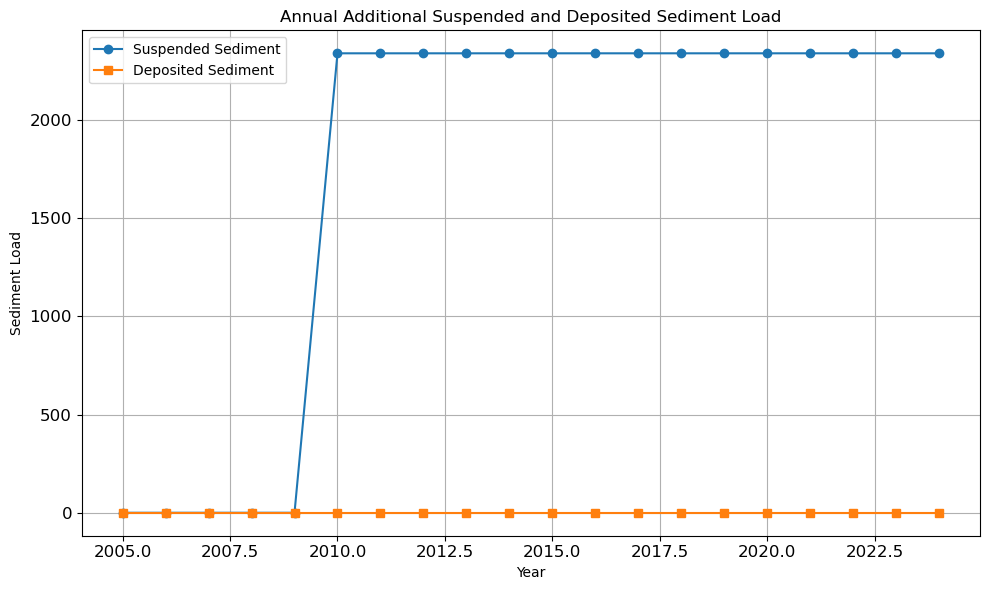

In [39]:
import matplotlib.pyplot as plt

# Build lists of years and sediment values
years = list(range(year_start, year_end + 1))
model_years = [y - year_start for y in years]

suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]

plt.figure(figsize=(10, 6))
plt.plot(years, suspended, label='Suspended Sediment', marker='o')
plt.plot(years, deposited, label='Deposited Sediment', marker='s')
plt.xlabel('Year')
plt.ylabel('Sediment Load')
plt.title('Annual Additional Suspended and Deposited Sediment Load')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

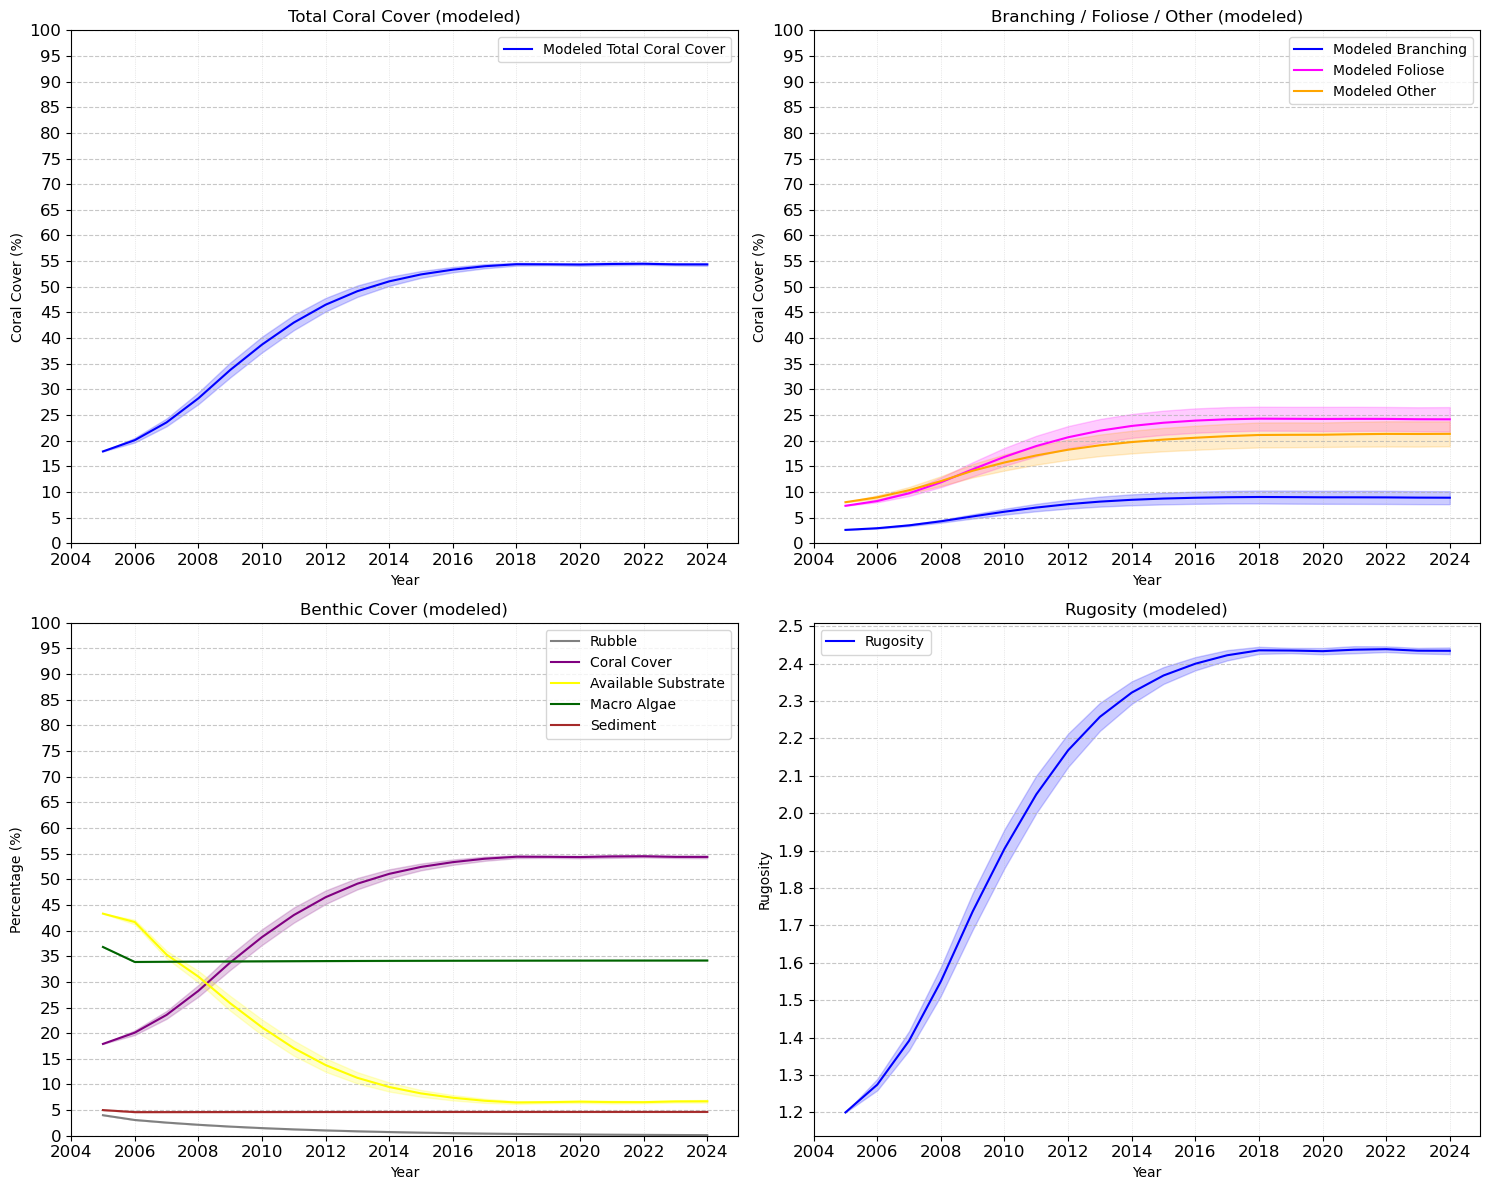

In [40]:
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator

# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the average and standard deviation for each morphology (model only)
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

# Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Helper to add horizontal guidelines every 10 units (or smaller step if range < 10)
def add_y_guidelines(ax, ymin=None, ymax=None, major_step=5):
    if ymin is None or ymax is None:
        ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    if yrange <= 0:
        return
    step = major_step if yrange >= major_step else round(yrange / 4, 3) or major_step
    # if step is 0 or too small, set sensible default
    if step == 0:
        step = major_step
    ax.yaxis.set_major_locator(MultipleLocator(step))
    ax.grid(which='major', axis='y', linestyle='--', linewidth=0.8, alpha=0.7)
    # keep lightweight vertical grid for reference
    ax.grid(which='major', axis='x', linestyle=':', linewidth=0.5, alpha=0.5)

# Plot Total Coral Cover (model only)
axs[0, 0].plot(actual_years, average_total.astype(float), label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years,
                       (average_total - std_dev_total).astype(float),
                       (average_total + std_dev_total).astype(float),
                       color='blue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover (modeled)')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 100)
axs[0, 0].set_xticks(actual_years)
axs[0, 0].set_xticklabels([f'{int(year)}' for year in actual_years])
add_y_guidelines(axs[0,0], ymin=0, ymax=100, major_step=5)

# Plot Branching, Foliose, and Other Coral Cover (model only)
axs[0, 1].plot(actual_years, average_branching.astype(float), label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years,
                       (average_branching - std_dev_branching).astype(float),
                       (average_branching + std_dev_branching).astype(float),
                       color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose.astype(float), label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years,
                       (average_foliose - std_dev_foliose).astype(float),
                       (average_foliose + std_dev_foliose).astype(float),
                       color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other.astype(float), label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years,
                       (average_other - std_dev_other).astype(float),
                       (average_other + std_dev_other).astype(float),
                       color='orange', alpha=0.2)
axs[0, 1].set_title('Branching / Foliose / Other (modeled)')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])
add_y_guidelines(axs[0,1], ymin=0, ymax=100, major_step=5)

# Plot Benthic Cover (model only)
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover (modeled)')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])
add_y_guidelines(axs[1,0], ymin=0, ymax=100, major_step=5)

# Plot Rugosity (model only)
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity (modeled)')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])
# rugosity axis range is typically small -> choose a smaller guideline step
ymin_r, ymax_r = axs[1,1].get_ylim()
add_y_guidelines(axs[1,1], ymin=ymin_r, ymax=ymax_r, major_step=0.1)

# After your plotting code:
# Get current x-axis limits for top-left (used to build year ticks)
xlim = axs[0, 0].get_xlim()
year_ticks = list(range(int(xlim[0]), int(xlim[1]) + 1, 2))
for ax in axs.flatten():
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs_modeled_only.png')
plt.savefig(graph_path)
plt.show()

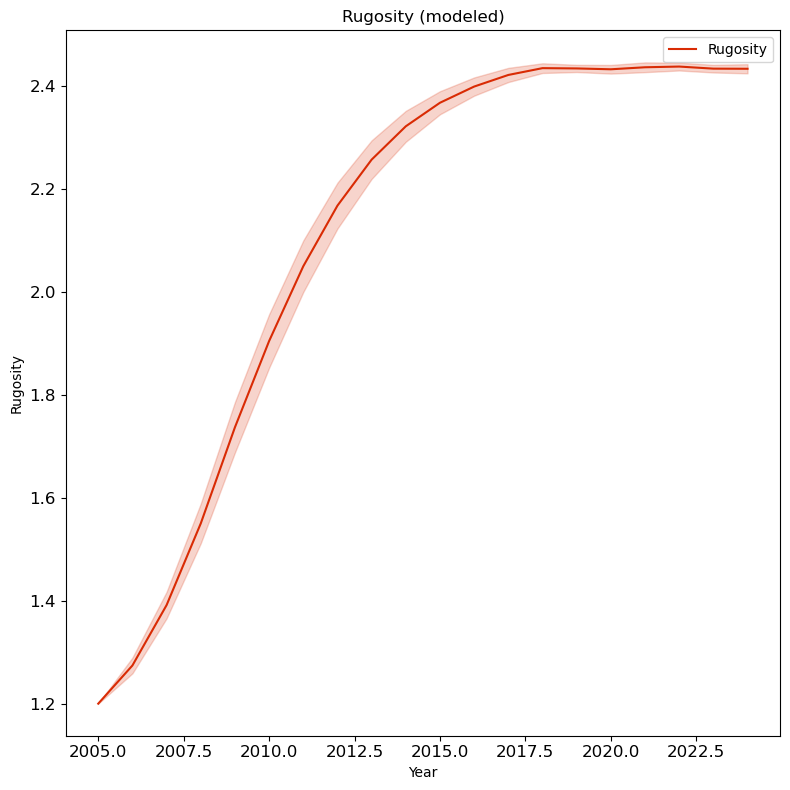

Saved rugosity SVG -> output\figures\rugosity.svg


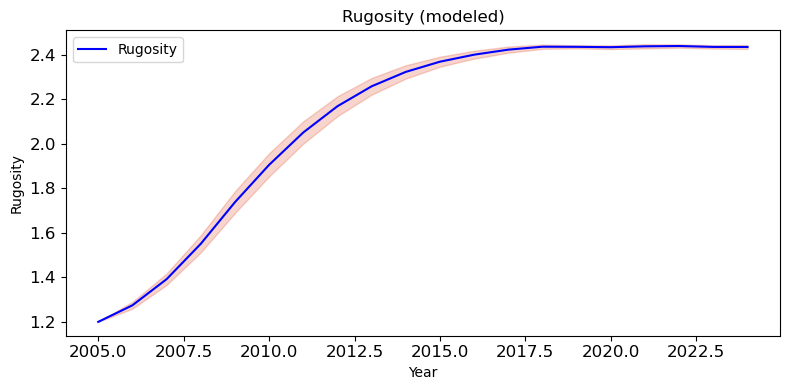

Saved rugosity SVG -> output\figures\rugosity.svg


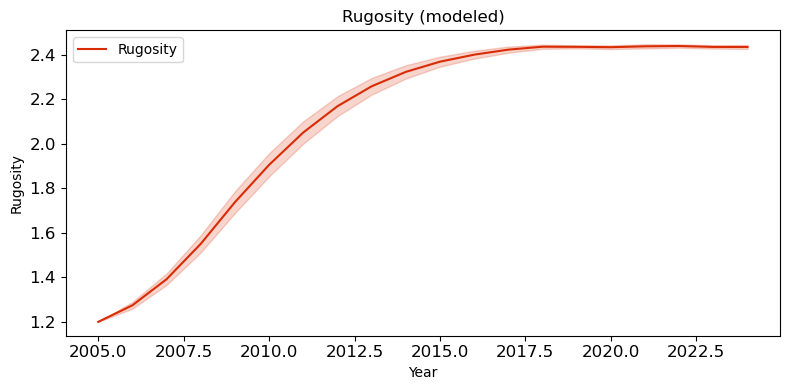

In [41]:
import os
import matplotlib.pyplot as plt

# compute mean + std (if variables already exist you can skip recomputing)
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# convert model years -> actual years if Year is model index
years = average_rugosity.index
if np.nanmax(years) < 1000:
    actual_years = [int(y) + int(year_start) for y in years]
else:
    actual_years = [int(y) for y in years]

# create plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(actual_years, average_rugosity, label='Rugosity', color='#D92B04' \
'')
ax.fill_between(actual_years,
                (average_rugosity - std_dev_rugosity).astype(float),
                (average_rugosity + std_dev_rugosity).astype(float),
                color='#D92B04', alpha=0.2)
ax.set_title('Rugosity (modeled)')
ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.legend()
ax.grid(False)
plt.tight_layout()

# ensure output folder exists and save as SVG
out_dir = os.path.join('output', 'figures')
os.makedirs(out_dir, exist_ok=True)
svg_path = os.path.join(out_dir, 'rugosity.svg')
plt.savefig(svg_path, format='svg', bbox_inches='tight')
plt.show()

print(f"Saved rugosity SVG -> {svg_path}")
#filepath: c:\Users\uqrbutto\OneDrive - The University of Queensland\PhD_proj_pollution_on_coral_reefs
import os
import matplotlib.pyplot as plt

# compute mean + std (if variables already exist you can skip recomputing)
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# convert model years -> actual years if Year is model index
years = average_rugosity.index
if np.nanmax(years) < 1000:
    actual_years = [int(y) + int(year_start) for y in years]
else:
    actual_years = [int(y) for y in years]

# create plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(actual_years, average_rugosity, label='Rugosity', color='blue')
ax.fill_between(actual_years,
                (average_rugosity - std_dev_rugosity).astype(float),
                (average_rugosity + std_dev_rugosity).astype(float),
                color='#D92B04', alpha=0.2)
ax.set_title('Rugosity (modeled)')
ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.legend()
ax.grid(False)
plt.tight_layout()

# ensure output folder exists and save as SVG
out_dir = os.path.join('output', 'figures')
os.makedirs(out_dir, exist_ok=True)
svg_path = os.path.join(out_dir, 'rugosity.svg')
plt.savefig(svg_path, format='svg', bbox_inches='tight')
plt.show()

print(f"Saved rugosity SVG -> {svg_path}")# os
import matplotlib.pyplot as plt

# compute mean + std (if variables already exist you can skip recomputing)
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# convert model years -> actual years if Year is model index
years = average_rugosity.index
if np.nanmax(years) < 1000:
    actual_years = [int(y) + int(year_start) for y in years]
else:
    actual_years = [int(y) for y in years]

# create plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(actual_years, average_rugosity, label='Rugosity', color='#D92B04')
ax.fill_between(actual_years,
                (average_rugosity - std_dev_rugosity).astype(float),
                (average_rugosity + std_dev_rugosity).astype(float),
                color='#D92B04', alpha=0.2)
ax.set_title('Rugosity (modeled)')
ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.legend()
ax.grid(False)
plt.tight_layout()

# ensure output folder exists and save as SVG
out_dir = os.path.join('output', 'figures')
os.makedirs(out_dir, exist_ok=True)
svg_path = os.path.join(out_dir, 'rugosity.svg')
plt.savefig(svg_path, format='svg', bbox_inches='tight')
plt.show()

#print(f"Saved rugosity SVG -> {svg_path}")

In [42]:
import winsound
winsound.Beep(1000, 2000)  # 1000 Hz for 200 ms